In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

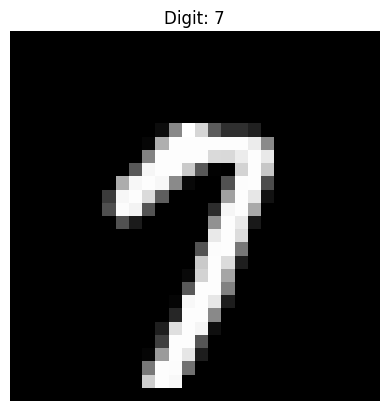

In [19]:
train_path = "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training"
digit_folder = os.path.join(train_path, "7")
image_name = os.listdir(digit_folder)[0]
image_path = os.path.join(digit_folder, image_name)
image = Image.open(image_path).convert("L")
plt.imshow(image, cmap="gray")
plt.title("Digit: 7")
plt.axis("off")
plt.show()

In [5]:
image_array=np.array(image)  #convert image into array
print("Shape of Image :",image_array.shape)
print("Data Type :",image_array.dtype)
print("Minimum Pixel value :",image_array.min())
print("Maximum Pixel value :",image_array.max())

Shape of Image : (28, 28)
Data Type : uint8
Minimum Pixel value : 0
Maximum Pixel value : 255


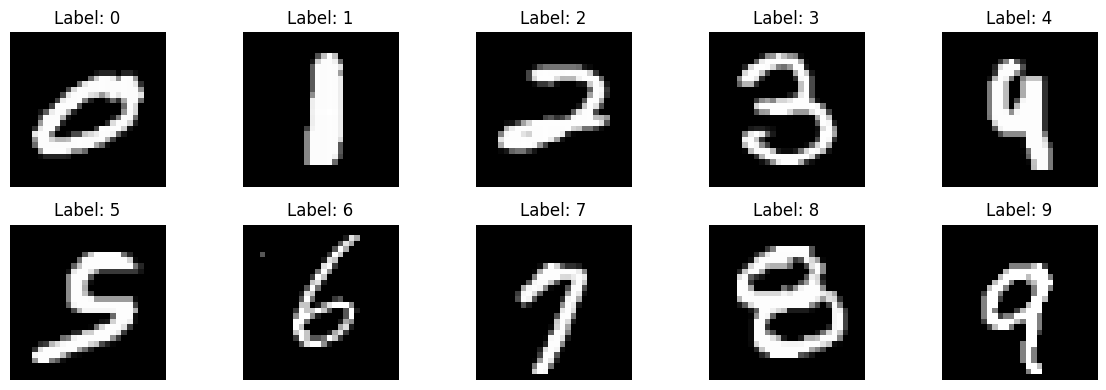

In [20]:
plt.figure(figsize=(12, 4))

for digit in range(10):
    folder_path = os.path.join(train_path, str(digit))
    image_name = os.listdir(folder_path)[0]
    image_path = os.path.join(folder_path, image_name)
    image = Image.open(image_path).convert("L")
    plt.subplot(2, 5, digit + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"Label: {digit}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
image_array = np.array(image)
normalized_image = image_array / 255.0
print("Minimum Pixel Value :", normalized_image.min())
print("Maximum Pixel Value :", normalized_image.max())
print("Data Type :", normalized_image.dtype)

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0
Data Type : float64


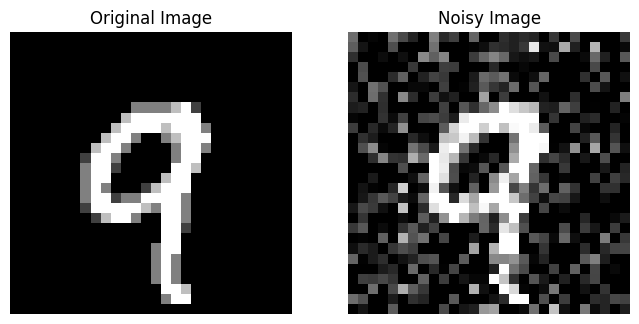

In [23]:
noise_factor = 0.3
noise = np.random.normal(loc=0.0, scale=1.0, size=normalized_image.shape)
noisy_image = normalized_image + noise_factor * noise
noisy_image = np.clip(noisy_image, 0., 1.)

#original Images
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(normalized_image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

#Noisy Image
plt.subplot(1,2,2)
plt.imshow(noisy_image, cmap="gray")
plt.title("Noisy Image")
plt.axis("off")

plt.show()

In [22]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.layers import Input


# input image defined
input_img = Input(shape=(28, 28, 1))
print(input_img)


<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_19>


In [12]:
x = Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation="relu",
    padding="same"
)(input_img)
print(x)

print("------------------------------------")
x = MaxPooling2D(
    pool_size=(2,2),
    padding="same"
)(x)
print(x)

print("------------------------------------")
x = Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation="relu",
    padding="same"
)(x)
print(x)
print("------------------------------------")

x = MaxPooling2D(
    pool_size=(2,2),
    padding="same"
)(x)

print(x)
print("------------------------------------")
x = Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation="relu",
    padding="same"
)(x)

print(x)
print("------------------------------------")

x = UpSampling2D(
    size=(2,2)
)(x)

print(x)
print("------------------------------------")
x = Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation="relu",
    padding="same"
)(x)

print(x)

x = UpSampling2D(
    size=(2,2)
)(x)

print(x)

decoded = Conv2D(
    filters=1,
    kernel_size=(3,3),
    activation="sigmoid",
    padding="same"
)(x)

print(decoded)

autoencoder = Model(
    input_img,
    decoded
)

autoencoder.summary()

<KerasTensor shape=(None, 28, 28, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_10>
------------------------------------
<KerasTensor shape=(None, 14, 14, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_11>
------------------------------------
<KerasTensor shape=(None, 14, 14, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_12>
------------------------------------
<KerasTensor shape=(None, 7, 7, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_13>
------------------------------------
<KerasTensor shape=(None, 7, 7, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_14>
------------------------------------
<KerasTensor shape=(None, 14, 14, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_15>
------------------------------------
<KerasTensor shape=(None, 14, 14, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_16>
<KerasTensor shape=(None, 28, 28, 32), dtype=float32, 

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

In [32]:
def load_images(folder_path):

    images = []

    for digit in range(10):

        digit_folder = os.path.join(folder_path, str(digit))

        for image_name in os.listdir(digit_folder):

            image_path = os.path.join(digit_folder, image_name)

            image = Image.open(image_path).convert("L")

            image = np.array(image)

            images.append(image)
    

    return np.array(images)

In [37]:
x_train = load_images(train_path)

test_path = "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/testing"

x_test = load_images(test_path)


In [39]:
print("Training Images :", x_train.shape)
print("Testing Images :", x_test.shape)

x_train = x_train / 255.0
x_test = x_test / 255.0

print("Training Data Range:")
print("Minimum:", x_train.min())
print("Maximum:", x_train.max())

print("\nTesting Data Range:")
print("Minimum:", x_test.min())
print("Maximum:", x_test.max())

Training Images : (60000, 28, 28)
Testing Images : (10000, 28, 28)
Training Data Range:
Minimum: 0.0
Maximum: 1.0

Testing Data Range:
Minimum: 0.0
Maximum: 1.0


In [41]:
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print("Training Shape :", x_train.shape)
print("Testing Shape :", x_test.shape)


noise_factor = 0.3
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Training Noisy Shape :", x_train_noisy.shape)
print("Testing Noisy Shape :", x_test_noisy.shape)

Training Shape : (60000, 28, 28, 1)
Testing Shape : (10000, 28, 28, 1)
Training Noisy Shape : (60000, 28, 28, 1)
Testing Noisy Shape : (10000, 28, 28, 1)


In [42]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=32,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - loss: 0.0980 - val_loss: 0.0814
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - loss: 0.0806 - val_loss: 0.0788
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - loss: 0.0787 - val_loss: 0.0781
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - loss: 0.0778 - val_loss: 0.0775
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - loss: 0.0772 - val_loss: 0.0766
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - loss: 0.0768 - val_loss: 0.0763
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - loss: 0.0766 - val_loss: 0.0763
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - loss: 0.0764 - val_loss: 0.0758
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - loss: 0.0762 - val_loss: 0.0757
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - loss: 0.0761 - val_loss: 0.0756


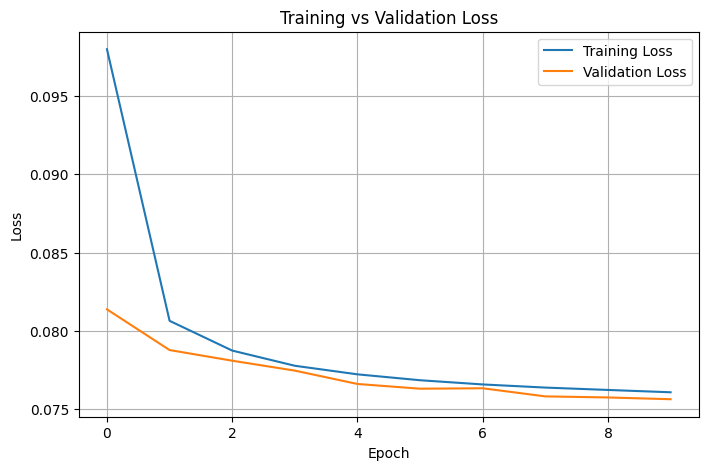

In [43]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Prediction Completed!
Shape of Decoded Images: (10000, 28, 28, 1)


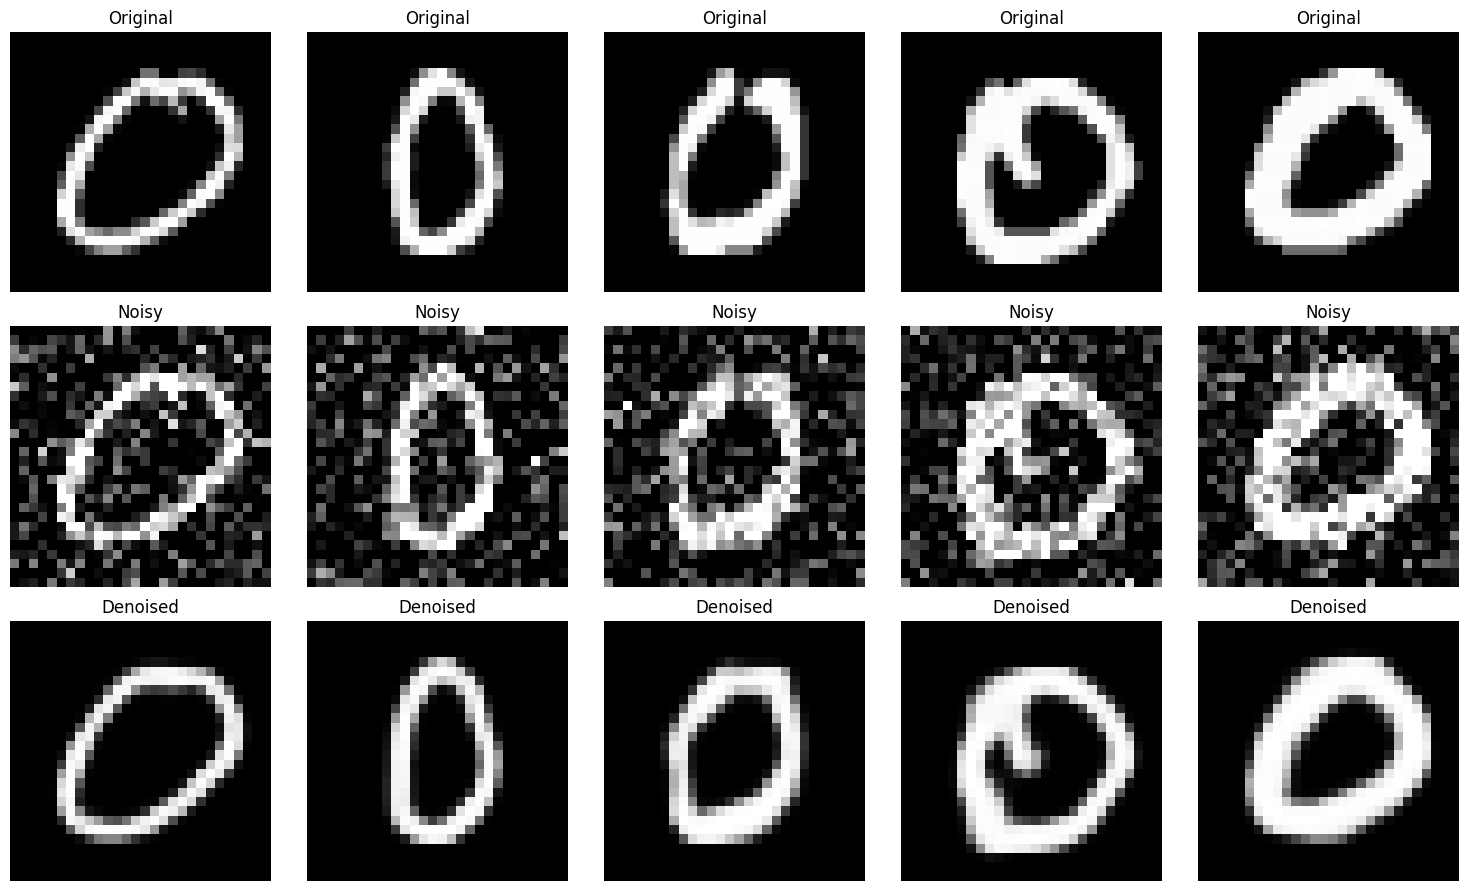

In [45]:
decoded_images = autoencoder.predict(x_test_noisy)

print("Prediction Completed!")
print("Shape of Decoded Images:", decoded_images.shape)

n = 5

plt.figure(figsize=(15, 9))

for i in range(n):

    #Original Img
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    #NoisyImg
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")
    #DenoiseImg
    plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_images[i].reshape(28, 28), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

Reconstruction Error: 0.004696188199051205


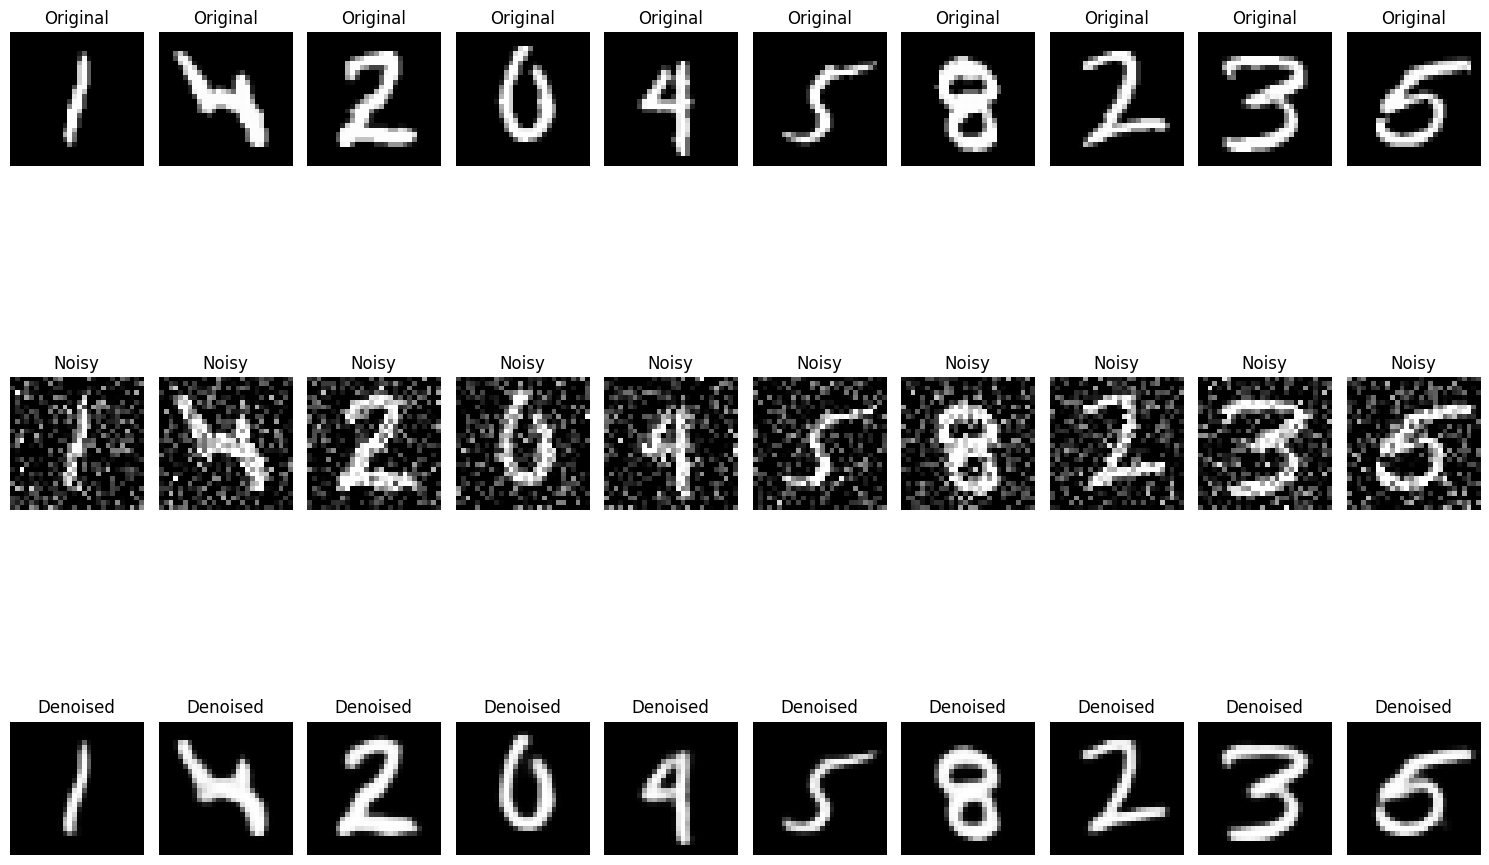

In [47]:
reconstruction_error = np.mean(np.square(x_test - decoded_images))
print("Reconstruction Error:", reconstruction_error)


# Display 10 Random test Imgs

import random
plt.figure(figsize=(15, 12))

for i in range(10):

    index = random.randint(0, len(x_test) - 1)

    # Orgnl
    plt.subplot(3, 10, i + 1)
    plt.imshow(x_test[index].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy
    plt.subplot(3, 10, i + 11)
    plt.imshow(x_test_noisy[index].reshape(28, 28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    plt.subplot(3, 10, i + 21)
    plt.imshow(decoded_images[index].reshape(28, 28), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [50]:
from tensorflow.keras.layers import Dropout, BatchNormalization

input_img = Input(shape=(28,28,1))

# ---------- Encoder ----------

x = Conv2D(32,(3,3),activation="relu",padding="same")(input_img)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2),padding="same")(x)
x = Dropout(0.2)(x)

x = Conv2D(64,(3,3),activation="relu",padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2),padding="same")(x)

#Bottleneck

x = Conv2D(128,(3,3),activation="relu",padding="same")(x)

# Decoder

x = UpSampling2D((2,2))(x)

x = Conv2D(64,(3,3),activation="relu",padding="same")(x)
x = BatchNormalization()(x)

x = UpSampling2D((2,2))(x)

x = Conv2D(32,(3,3),activation="relu",padding="same")(x)

decoded = Conv2D(1,(3,3),activation="sigmoid",padding="same")(x)

improved_autoencoder = Model(input_img,decoded)

improved_autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,857 (726.00 KB)

 Trainable params: 185,537 (724.75 KB)

 Non-trainable params: 320 (1.25 KB)

In [55]:
improved_autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

history2 = improved_autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test_noisy,x_test),
    shuffle=True
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 165s 87ms/step - loss: 0.0851 - val_loss: 0.0770
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 155s 83ms/step - loss: 0.0777 - val_loss: 0.0756
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 157s 84ms/step - loss: 0.0766 - val_loss: 0.0752
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 157s 84ms/step - loss: 0.0762 - val_loss: 0.0747
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 157s 84ms/step - loss: 0.0758 - val_loss: 0.0744
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 203s 85ms/step - loss: 0.0755 - val_loss: 0.0742
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 156s 83ms/step - loss: 0.0753 - val_loss: 0.0749
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 158s 84ms/step - loss: 0.0751 - val_loss: 0.0744
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 159s 85ms/step - loss: 0.0749 - val_loss: 0.0739
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 159s 85ms/step - loss: 0.0748 - val_loss: 0.0740


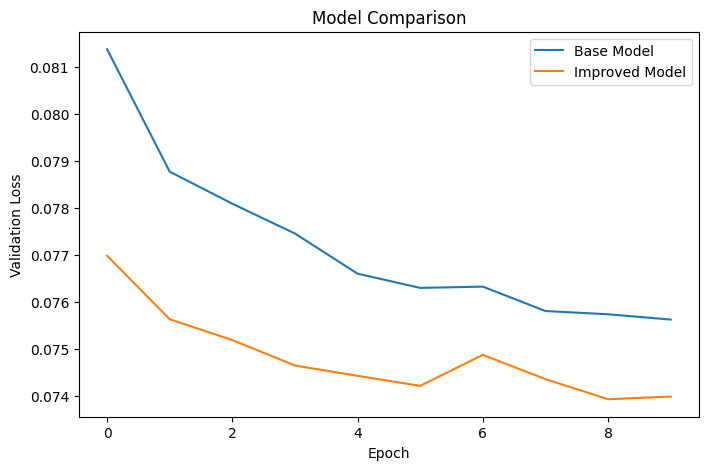

In [56]:
plt.figure(figsize=(8,5))

plt.plot(history.history["val_loss"],label="Base Model")
plt.plot(history2.history["val_loss"],label="Improved Model")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Model Comparison")

plt.legend()

plt.show()